In [1]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================
# WHY: We need to install two packages that don't come pre-installed:
#
#   - ultralytics: This is the company that makes YOLO models.
#     Installing this gives us access to YOLO26 (their latest model).
#     IMPORTANT: We need the LATEST version to get YOLO26 support.
#     Older versions only have YOLOv8/YOLO11.
#
#   - roboflow: This lets us download datasets from Roboflow Universe
#     directly into our Kaggle notebook using Python code.
#
# WHAT "pip install" MEANS:
#   - pip = Python's package manager (like an app store for Python)
#   - install = download and set up the package
#   - -U = "upgrade" to the latest version (critical for YOLO26!)
#   - -q = "quiet" mode, shows less text output (cleaner)
# ============================================================

!pip install -U -q ultralytics roboflow

# Verify the installation worked and YOLO26 is available
import ultralytics
ultralytics.checks()  # Prints version info and confirms GPU is available

print(f"\n✅ Ultralytics version: {ultralytics.__version__}")
print("   (YOLO26 requires version 8.3+ — check above!)")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 6997.5/8062.4 GB disk)

✅ Ultralytics version: 8.4.90
   (YOLO26 requires version 8.3+ — check above!)


In [2]:
# ============================================================
# CELL 2: GET YOUR ROBOFLOW API KEY FROM KAGGLE SECRETS
# ============================================================
# WHY: Roboflow needs to verify you're a real user before letting
# you download datasets. Your API key is like a password.
#
# HOW KAGGLE SECRETS WORK:
#   - Instead of typing your API key directly in the code (UNSAFE!
#     anyone who sees your notebook could steal it), Kaggle stores
#     it securely in their "Secrets" vault.
#   - The UserSecretsClient reads it from the vault at runtime.
#   - This way, your key never appears in your code.
#
# IMPORTANT: If you named your secret differently than
# "ROBOFLOW_API_KEY", change the string below to match YOUR name.
# ============================================================

from kaggle_secrets import UserSecretsClient

# Create a "client" that can talk to Kaggle's secrets vault
user_secrets = UserSecretsClient()

# Retrieve your API key by its name (must match what you entered in Kaggle)
ROBOFLOW_API_KEY = user_secrets.get_secret("ROBOFLOW_API_KEY")

# Quick sanity check (prints first 4 chars only, for security)
print(f"✅ API Key loaded successfully! Starts with: {ROBOFLOW_API_KEY[:4]}...")

✅ API Key loaded successfully! Starts with: BiTV...


In [3]:
# ============================================================
# CELL 3: DOWNLOAD ALL 5 DATASETS FROM ROBOFLOW UNIVERSE
# ============================================================
# WHY: We want our model to detect BOTH lying and sitting people.
# No single dataset has enough images of both, so we combine 5
# different datasets to get more training data.
#
# HOW ROBOFLOW DOWNLOAD WORKS:
#   1. rf = Roboflow(api_key=...) → Logs you in
#   2. rf.workspace("name") → Goes to a user's workspace
#   3. .project("name") → Opens a specific project
#   4. .version(N) → Selects a specific version of the dataset
#   5. .download("yolov8") → Downloads it in YOLO format
#
# WHY "yolov8" FORMAT WHEN WE'RE USING YOLO26?
#   YOLO26 uses the EXACT SAME label format as YOLOv8!
#   The format is:
#     - Images in folders: train/images/, valid/images/, test/images/
#     - Labels in folders: train/labels/, valid/labels/, test/labels/
#     - Each label file (.txt) has one line per detected object:
#       class_id  x_center  y_center  width  height
#       (all values are normalized between 0.0 and 1.0)
#
# ⚠️ VERSION NUMBERS: Each dataset has versions (like app updates).
#   I'm using version 1 for each. If a dataset doesn't have version 1,
#   visit the URL, check the "Versions" tab, and update the number.
# ============================================================

from roboflow import Roboflow
import os

# Log into Roboflow with your API key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Define all 5 datasets we want to download
# Each entry: (workspace_name, project_name, version_number, description)
datasets_to_download = [
    ("hyeonchul-jung", "lying-person",          1, "Lying Person"),
    ("itenas-jbtoe",   "sitting-q96qq",         1, "Sitting (ITENAS)"),
    ("welcome-rpojx",  "sitting-dbnbk",         1, "Sitting (Welcome)"),
    ("rr-qhwfw",       "sitting-x9rcm",         1, "Sitting (RR)"),
    ("hook-works",     "sitting-posture-3sqgz",  1, "Sitting Posture"),
]

# Download each dataset
downloaded_paths = []
for workspace, project, version, desc in datasets_to_download:
    print(f"\n{'='*60}")
    print(f"📥 Downloading: {desc}")
    print(f"   From: universe.roboflow.com/{workspace}/{project}")
    print(f"{'='*60}")

    try:
        ds = rf.workspace(workspace).project(project).version(version)
        ds_download = ds.download("yolov8")
        downloaded_paths.append(ds_download.location)
        print(f"✅ Success! Saved to: {ds_download.location}")
    except Exception as e:
        print(f"❌ Error downloading {desc}: {e}")
        print(f"   💡 TIP: Visit the URL above, check the Versions tab,")
        print(f"   and update the version number in the code.")

print(f"\n{'='*60}")
print(f"📊 Successfully downloaded {len(downloaded_paths)} / {len(datasets_to_download)} datasets")
for p in downloaded_paths:
    print(f"   📁 {p}")


📥 Downloading: Lying Person
   From: universe.roboflow.com/hyeonchul-jung/lying-person
loading Roboflow workspace...
loading Roboflow project...
❌ Error downloading Lying Person: Version number 1 is not found.
   💡 TIP: Visit the URL above, check the Versions tab,
   and update the version number in the code.

📥 Downloading: Sitting (ITENAS)
   From: universe.roboflow.com/itenas-jbtoe/sitting-q96qq
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sitting-1 in yolov8:: 100%|██████████| 424/424 [00:00<00:00, 11986.88it/s]

✅ Success! Saved to: /kaggle/working/Sitting-1

📥 Downloading: Sitting (Welcome)
   From: universe.roboflow.com/welcome-rpojx/sitting-dbnbk
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to sitting-1 in yolov8:: 100%|██████████| 618/618 [00:00<00:00, 2858.51it/s]

✅ Success! Saved to: /kaggle/working/sitting-1

📥 Downloading: Sitting (RR)
   From: universe.roboflow.com/rr-qhwfw/sitting-x9rcm
loading Roboflow workspace...


loading Roboflow project...
✅ Success! Saved to: /kaggle/working/sitting-1

📥 Downloading: Sitting Posture
   From: universe.roboflow.com/hook-works/sitting-posture-3sqgz
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to sitting-posture-1 in yolov8:: 100%|██████████| 103/103 [00:00<00:00, 9217.27it/s]

✅ Success! Saved to: /kaggle/working/sitting-posture-1

📊 Successfully downloaded 4 / 5 datasets
   📁 /kaggle/working/Sitting-1
   📁 /kaggle/working/sitting-1
   📁 /kaggle/working/sitting-1
   📁 /kaggle/working/sitting-posture-1


In [4]:
# ============================================================
# CELL 4: MERGE ALL 5 DATASETS INTO A SINGLE UNIFIED DATASET
# ============================================================
# WHY WE NEED TO MERGE:
#   Each dataset has its OWN class numbers. For example:
#   - Dataset A might use: 0 = "lying"
#   - Dataset B might use: 0 = "sitting", 1 = "standing"
#   - Dataset C might use: 0 = "person_sitting"
#
#   If we just dump them together, class "0" would mean different
#   things in different images → the model would be VERY confused!
#
# WHAT THIS CODE DOES:
#   1. Reads each dataset's data.yaml to learn its class names
#   2. Maps every class to our unified system:
#        0 = lying_person
#        1 = sitting_person
#   3. Copies all images to one merged folder
#   4. Rewrites all label files with the corrected class numbers
#   5. Creates a new data.yaml for the merged dataset
# ============================================================

import shutil
import yaml
import glob
from pathlib import Path

# ---- CONFIGURATION ----
MERGED_DIR = "/kaggle/working/merged_dataset"
UNIFIED_CLASSES = {
    0: "lying_person",
    1: "sitting_person"
}

# Keywords to identify which class a label belongs to
# (We check if ANY of these words appear in the original class name)
LYING_KEYWORDS  = ["lying", "lie", "lay", "fallen", "fall", "down"]
SITTING_KEYWORDS = ["sit", "sitting", "seated", "posture"]

def classify_label(original_class_name):
    """
    Takes an original class name (like 'person_lying_down') and
    maps it to our unified class ID (0 for lying, 1 for sitting).

    Returns: unified class ID (int) or None if we can't classify it
    """
    name_lower = original_class_name.lower()

    for keyword in LYING_KEYWORDS:
        if keyword in name_lower:
            return 0  # lying_person

    for keyword in SITTING_KEYWORDS:
        if keyword in name_lower:
            return 1  # sitting_person

    # If the class is just "person" or something generic,
    # we'll try to infer from the dataset name later
    return None

# ---- CREATE MERGED DIRECTORY STRUCTURE ----
for split in ["train", "valid", "test"]:
    os.makedirs(f"{MERGED_DIR}/{split}/images", exist_ok=True)
    os.makedirs(f"{MERGED_DIR}/{split}/labels", exist_ok=True)

print("📁 Created merged directory structure:")
print(f"   {MERGED_DIR}/")
print(f"   ├── train/images/  &  train/labels/")
print(f"   ├── valid/images/  &  valid/labels/")
print(f"   └── test/images/   &  test/labels/")

# ---- MERGE EACH DATASET ----
total_images = 0
total_labels = 0
skipped_classes = set()

for idx, dataset_path in enumerate(downloaded_paths):
    dataset_name = os.path.basename(dataset_path)
    print(f"\n{'='*60}")
    print(f"🔄 Processing dataset {idx+1}/{len(downloaded_paths)}: {dataset_name}")
    print(f"   Path: {dataset_path}")

    # Step 1: Read the dataset's data.yaml to get its class names
    yaml_path = os.path.join(dataset_path, "data.yaml")
    if not os.path.exists(yaml_path):
        print(f"   ⚠️ No data.yaml found, skipping...")
        continue

    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    original_classes = data_config.get('names', {})
    # Handle both list format ['cls1', 'cls2'] and dict format {0: 'cls1', 1: 'cls2'}
    if isinstance(original_classes, list):
        original_classes = {i: name for i, name in enumerate(original_classes)}

    print(f"   📋 Original classes: {original_classes}")

    # Step 2: Build a mapping from original class IDs to unified IDs
    class_mapping = {}

    # Determine the "default" class based on dataset name
    # (for datasets where class names are generic like "person" or "0")
    is_lying_dataset = any(kw in dataset_name.lower() for kw in ["lying", "lie", "lay"])
    is_sitting_dataset = any(kw in dataset_name.lower() for kw in ["sit", "posture"])

    for orig_id, orig_name in original_classes.items():
        unified_id = classify_label(orig_name)

        # If we couldn't classify by name, use the dataset name as a hint
        if unified_id is None:
            if is_lying_dataset:
                unified_id = 0  # lying_person
            elif is_sitting_dataset:
                unified_id = 1  # sitting_person
            else:
                print(f"   ⚠️ Can't classify '{orig_name}' (ID {orig_id}), skipping")
                skipped_classes.add(orig_name)
                continue

        class_mapping[int(orig_id)] = unified_id

    print(f"   🔀 Class mapping: {class_mapping}")

    # Step 3: Copy images and rewrite labels for each split
    for split in ["train", "valid", "test"]:
        img_src_dir = os.path.join(dataset_path, split, "images")
        lbl_src_dir = os.path.join(dataset_path, split, "labels")

        if not os.path.exists(img_src_dir):
            continue

        img_files = glob.glob(os.path.join(img_src_dir, "*"))

        for img_file in img_files:
            # Create a unique filename by prefixing with dataset index
            # (prevents name collisions between datasets)
            original_name = os.path.basename(img_file)
            unique_name = f"ds{idx}_{original_name}"

            # Copy image
            dst_img = os.path.join(MERGED_DIR, split, "images", unique_name)
            shutil.copy2(img_file, dst_img)
            total_images += 1

            # Find and process the corresponding label file
            label_name = os.path.splitext(original_name)[0] + ".txt"
            src_label = os.path.join(lbl_src_dir, label_name)
            dst_label = os.path.join(MERGED_DIR, split, "labels",
                                      f"ds{idx}_{label_name}")

            if os.path.exists(src_label):
                # Read the original label, remap class IDs, write new label
                with open(src_label, 'r') as f:
                    lines = f.readlines()

                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        orig_class_id = int(parts[0])
                        if orig_class_id in class_mapping:
                            # Replace old class ID with unified ID
                            parts[0] = str(class_mapping[orig_class_id])
                            new_lines.append(" ".join(parts) + "\n")

                with open(dst_label, 'w') as f:
                    f.writelines(new_lines)
                total_labels += 1

        count = len(img_files)
        print(f"   📸 {split}: {count} images copied")

# ---- SUMMARY ----
print(f"\n{'='*60}")
print(f"✅ MERGE COMPLETE!")
print(f"   📸 Total images: {total_images}")
print(f"   🏷️  Total labels: {total_labels}")
if skipped_classes:
    print(f"   ⚠️  Skipped classes: {skipped_classes}")
print(f"   📁 Merged dataset: {MERGED_DIR}")

📁 Created merged directory structure:
   /kaggle/working/merged_dataset/
   ├── train/images/  &  train/labels/
   ├── valid/images/  &  valid/labels/
   └── test/images/   &  test/labels/

🔄 Processing dataset 1/4: Sitting-1
   Path: /kaggle/working/Sitting-1
   📋 Original classes: {0: 'sitting'}
   🔀 Class mapping: {0: 1}
   📸 train: 142 images copied
   📸 valid: 43 images copied
   📸 test: 21 images copied

🔄 Processing dataset 2/4: sitting-1
   Path: /kaggle/working/sitting-1
   📋 Original classes: {0: 'sitting'}
   🔀 Class mapping: {0: 1}
   📸 train: 212 images copied
   📸 valid: 61 images copied
   📸 test: 30 images copied

🔄 Processing dataset 3/4: sitting-1
   Path: /kaggle/working/sitting-1
   📋 Original classes: {0: 'sitting'}
   🔀 Class mapping: {0: 1}
   📸 train: 212 images copied
   📸 valid: 61 images copied
   📸 test: 30 images copied

🔄 Processing dataset 4/4: sitting-posture-1
   Path: /kaggle/working/sitting-posture-1
   📋 Original classes: {0: 'bad', 1: 'good'}
   🔀 C

In [5]:
# ============================================================
# CELL 5: CREATE THE data.yaml CONFIGURATION FILE
# ============================================================
# WHY: YOLO26 needs a "recipe card" (data.yaml) that tells it:
#   - WHERE to find training/validation/test images
#   - HOW MANY classes to detect
#   - WHAT each class is called
#
# WHAT IS YAML?
#   YAML is a simple text format for configuration files.
#   It uses indentation (like Python) instead of brackets.
#   Example:
#     train: /path/to/train/images
#     nc: 2
#     names:
#       0: lying_person
#       1: sitting_person
# ============================================================

import yaml

# Count images in each split to verify
for split in ["train", "valid", "test"]:
    img_dir = f"{MERGED_DIR}/{split}/images"
    count = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    print(f"   {split}: {count} images")

# Create the data.yaml configuration
data_yaml = {
    'train': f'{MERGED_DIR}/train/images',
    'val':   f'{MERGED_DIR}/valid/images',
    'test':  f'{MERGED_DIR}/test/images',
    'nc':    2,  # nc = Number of Classes
    'names': {
        0: 'lying_person',
        1: 'sitting_person'
    }
}

yaml_path = f"{MERGED_DIR}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

# Display what we just created
print(f"\n📄 Created: {yaml_path}")
print("─" * 40)
with open(yaml_path, 'r') as f:
    print(f.read())
print("─" * 40)
print("✅ Configuration file ready for YOLO26!")

   train: 612 images
   valid: 165 images
   test: 82 images

📄 Created: /kaggle/working/merged_dataset/data.yaml
────────────────────────────────────────
names:
  0: lying_person
  1: sitting_person
nc: 2
test: /kaggle/working/merged_dataset/test/images
train: /kaggle/working/merged_dataset/train/images
val: /kaggle/working/merged_dataset/valid/images

────────────────────────────────────────
✅ Configuration file ready for YOLO26!


In [6]:
# ============================================================
# CELL 6: TRAIN YOLO26n — THE MAIN EVENT! 🎉
# ============================================================
# This is where the AI actually LEARNS to detect lying and
# sitting people by studying thousands of labeled images.
#
# ═══════════════════════════════════════════════════════════
# WHAT EACH PARAMETER MEANS:
# ═══════════════════════════════════════════════════════════
#
# model = "yolo26n.pt"
#   → The YOLO26 Nano model. This is the SMALLEST and FASTEST
#     variant with ~2.7 million parameters. Perfect for:
#     - Fast training on Kaggle's limited GPU time
#     - A 2-class problem (lying/sitting) doesn't need a huge model
#     - Later deployment on mobile devices or edge hardware
#     The ".pt" file contains PRE-TRAINED weights — the model
#     already knows basic shapes, edges, and objects from being
#     trained on millions of images (COCO dataset). This is
#     called "TRANSFER LEARNING" — we don't start from scratch.
#
# data = "path/to/data.yaml"
#   → Points to our configuration file from Cell 5
#
# epochs = 80
#   → How many times the model sees the ENTIRE dataset.
#     Think of it like re-reading a textbook:
#     - 1 epoch  = read once (barely learned anything)
#     - 20 epochs = starting to understand
#     - 80 epochs = solid understanding 🎯
#     - 300 epochs = might over-memorize (overfitting!)
#     We use 80 because YOLO26's Progressive Loss and MuSGD
#     optimizer converge faster than older YOLO versions.
#
# imgsz = 640
#   → The size (in pixels) to resize all images to.
#     Larger = more detail but slower training.
#     640 is the standard for YOLO26 detection.
#
# batch = 16
#   → How many images the model looks at simultaneously.
#     Higher = faster training but needs more GPU memory.
#     If you get "CUDA out of memory", reduce to 8 or 4.
#     yolo26n is small, so 16 should work fine on Kaggle T4.
#
# patience = 20
#   → "Early stopping" — if the model doesn't improve for
#     20 epochs in a row, stop training early (saves time).
#     We use 20 (not 15) because YOLO26's Progressive Loss
#     can have plateau phases before improving again.
#
# device = 0
#   → Use the first GPU (index 0). On Kaggle, this is
#     the Tesla T4 or P100 GPU you selected earlier.
#
# optimizer = "auto"
#   → YOLO26 will automatically select MuSGD (Muon-SGD),
#     its new hybrid optimizer. MuSGD combines:
#     - Muon: A momentum-based method that's great at escaping
#       local minima (spots where the model gets "stuck")
#     - SGD: Classic Stochastic Gradient Descent for stability
#     This makes training more stable and converge faster.
#
# cos_lr = True
#   → Use "cosine learning rate" schedule. The learning rate
#     starts high (learn fast), then gradually slows down
#     following a cosine curve (fine-tune carefully). Like
#     driving fast on a highway, then slowing in a parking lot.
#
# project & name
#   → Where to save results. Creates:
#     /kaggle/working/yolo26_results/lying_sitting_v1/
# ═══════════════════════════════════════════════════════════

from ultralytics import YOLO

# Step 1: Load the pre-trained YOLO26 Nano model
# (Downloads automatically on first run — about 6MB, very small!)
print("📦 Loading pre-trained YOLO26n model...")
print("   🆕 YOLO26 features: NMS-free detection, MuSGD optimizer,")
print("   Progressive Loss, and STAL small-target awareness\n")

model = YOLO("yolo26n.pt")

# Step 2: Start training!
print("🚂 Starting training... This will take 20-60 minutes on Kaggle GPU.")
print("   (yolo26n is fast because it's the Nano variant!)\n")

results = model.train(
    data=f"{MERGED_DIR}/data.yaml",       # Our config file
    epochs=80,                             # Number of full passes through data
    imgsz=640,                             # Image size (pixels)
    batch=16,                              # Images per batch
    patience=20,                           # Stop early if no improvement for 20 epochs
    device=0,                              # Use GPU
    project="/kaggle/working/yolo26_results",  # Save location
    name="lying_sitting_v1",               # Experiment name
    pretrained=True,                       # Use pre-trained weights (transfer learning)
    optimizer="auto",                      # Let YOLO26 use MuSGD automatically
    cos_lr=True,                           # Cosine learning rate schedule
    verbose=True,                          # Show detailed progress
    plots=True,                            # Generate training plots
)

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)

📦 Loading pre-trained YOLO26n model...
   🆕 YOLO26 features: NMS-free detection, MuSGD optimizer,
   Progressive Loss, and STAL small-target awareness

🚂 Starting training... This will take 20-60 minutes on Kaggle GPU.
   (yolo26n is fast because it's the Nano variant!)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0

In [7]:
# ============================================================
# CELL 7: EVALUATE THE TRAINED MODEL
# ============================================================
# WHY: We need to check if the model actually learned well.
# We test it on the VALIDATION set (images it has NEVER seen
# during training) to see how it performs on new data.
#
# KEY METRICS EXPLAINED:
#
# mAP50 (mean Average Precision at IoU 0.50):
#   → "If we consider a detection correct when the predicted box
#      overlaps 50%+ with the real box, how accurate is the model?"
#   → Score: 0.0 (terrible) to 1.0 (perfect)
#   → Good target: > 0.70 (70%)
#
# mAP50-95 (mean Average Precision at IoU 0.50:0.95):
#   → Same as above, but averaged across stricter overlaps
#     (50%, 55%, 60%... up to 95%). This is the HARDER metric.
#   → Good target: > 0.45 (45%)
#
# Precision:
#   → Of all the detections the model made, what % were correct?
#   → High precision = few false alarms
#
# Recall:
#   → Of all the real objects, what % did the model find?
#   → High recall = few missed detections
#
# WHAT IS IoU (Intersection over Union)?
#   → Measures how much the predicted box overlaps with the real box
#   → IoU = Area of Overlap / Area of Union
#   → 0.50 means 50% overlap (decent), 0.95 means near-perfect
#
# YOLO26 ADVANTAGE:
#   Because YOLO26 is NMS-free (end-to-end), the evaluation
#   pipeline is simpler and more accurate — no post-processing
#   artifacts that could affect metrics.
# ============================================================

from ultralytics import YOLO
import os

# Find the best model weights (automatically saved during training)
best_model_path = "/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.pt"

if os.path.exists(best_model_path):
    print(f"📦 Loading best model from: {best_model_path}")
    model = YOLO(best_model_path)

    # Run validation
    print("\n📊 Running evaluation on validation set...\n")
    metrics = model.val()

    # Print results in a readable format
    print("\n" + "="*60)
    print("📊 YOLO26n EVALUATION RESULTS")
    print("="*60)
    print(f"  📈 mAP50:    {metrics.box.map50:.4f}  (target: > 0.70)")
    print(f"  📈 mAP50-95: {metrics.box.map:.4f}  (target: > 0.45)")
    print(f"  🎯 Precision: {metrics.box.mp:.4f}")
    print(f"  🔍 Recall:    {metrics.box.mr:.4f}")

    # Per-class results
    print(f"\n  Per-class mAP50:")
    class_names = ["lying_person", "sitting_person"]
    for i, name in enumerate(class_names):
        if i < len(metrics.box.ap50):
            print(f"    {name}: {metrics.box.ap50[i]:.4f}")

    # Quality assessment
    map50 = metrics.box.map50
    if map50 > 0.80:
        print(f"\n  🌟 EXCELLENT! Your YOLO26n model is very accurate!")
        print(f"     Consider deploying as-is or exporting to mobile.")
    elif map50 > 0.65:
        print(f"\n  ✅ GOOD! Decent results for a Nano model.")
        print(f"     Try: more epochs, or upgrade to yolo26s.pt for better accuracy.")
    elif map50 > 0.45:
        print(f"\n  ⚠️ FAIR. Consider: more data, 120+ epochs, or yolo26s/m model.")
    else:
        print(f"\n  ❌ POOR. Check your dataset labels and class mappings in Cell 4.")
else:
    print(f"❌ Model not found at {best_model_path}")
    print("   Did training complete successfully in Cell 6?")

📦 Loading best model from: /kaggle/working/yolo26_results/lying_sitting_v1/weights/best.pt

📊 Running evaluation on validation set...

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1252.7±1507.0 MB/s, size: 257.1 KB)
val: Scanning /kaggle/working/merged_dataset/valid/labels.cache... 165 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 165/165 69.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.9it/s 2.8s
                   all        165        173      0.943      0.951      0.985      0.707
        sitting_person        165        173      0.943      0.951      0.985      0.707
Speed: 2.6ms preprocess, 4.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

📊 YOLO26n EVALUATION RESULTS
 


📈 Training & Validation Loss Curves
💡 All lines should trend DOWNWARD. If validation loss goes UP while training loss goes DOWN → overfitting (model is memorizing, not learning).


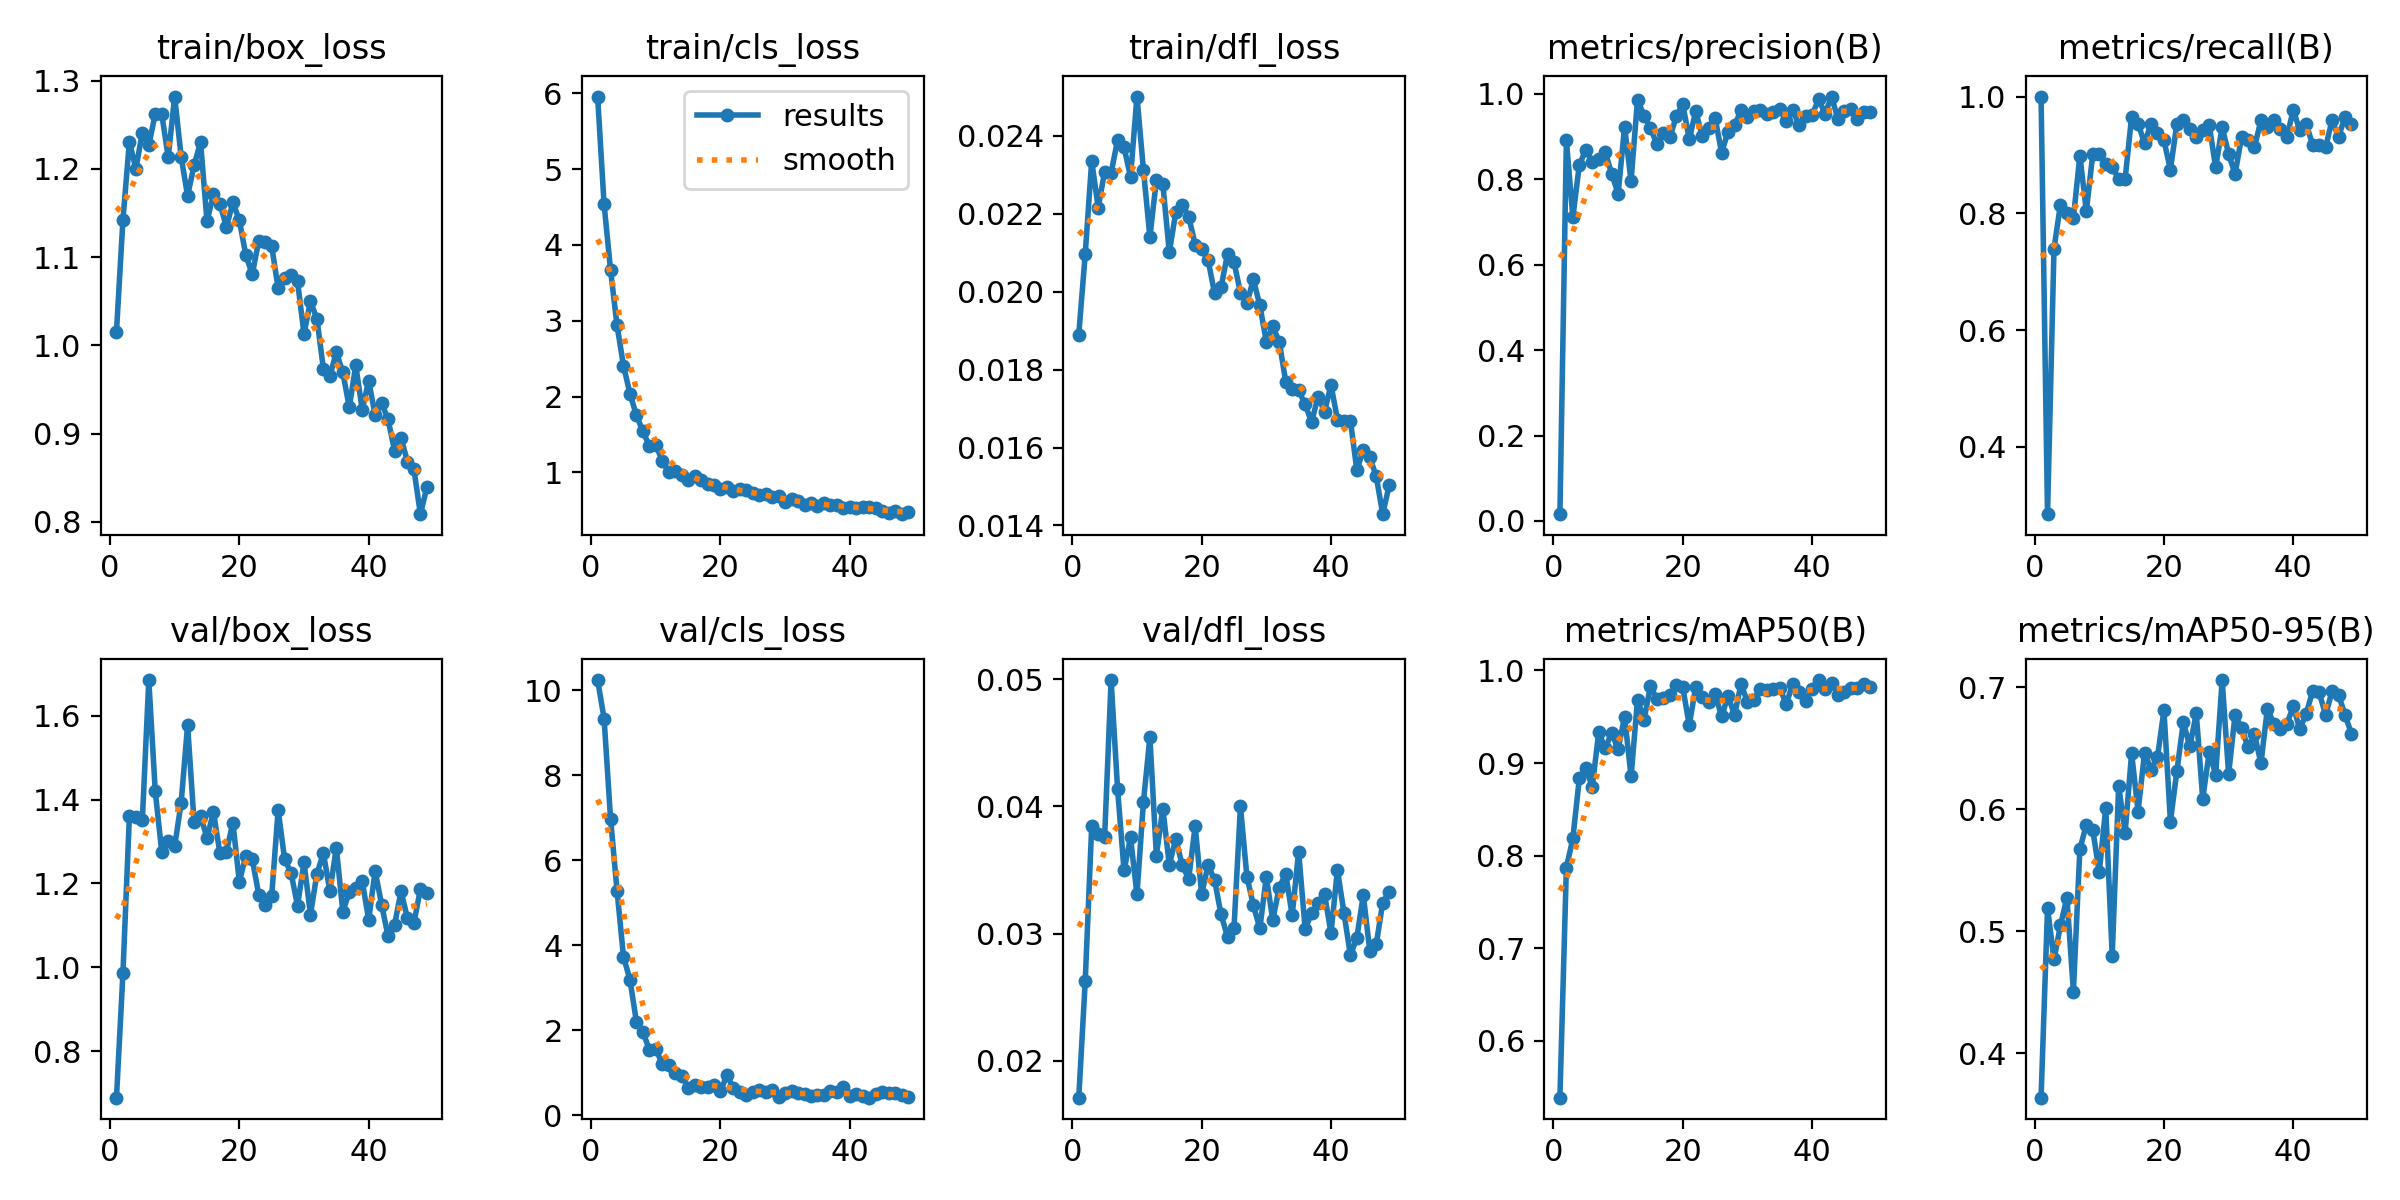


🔀 Confusion Matrix
💡 Diagonal = correct predictions. Off-diagonal = mistakes. High numbers on the diagonal = good!


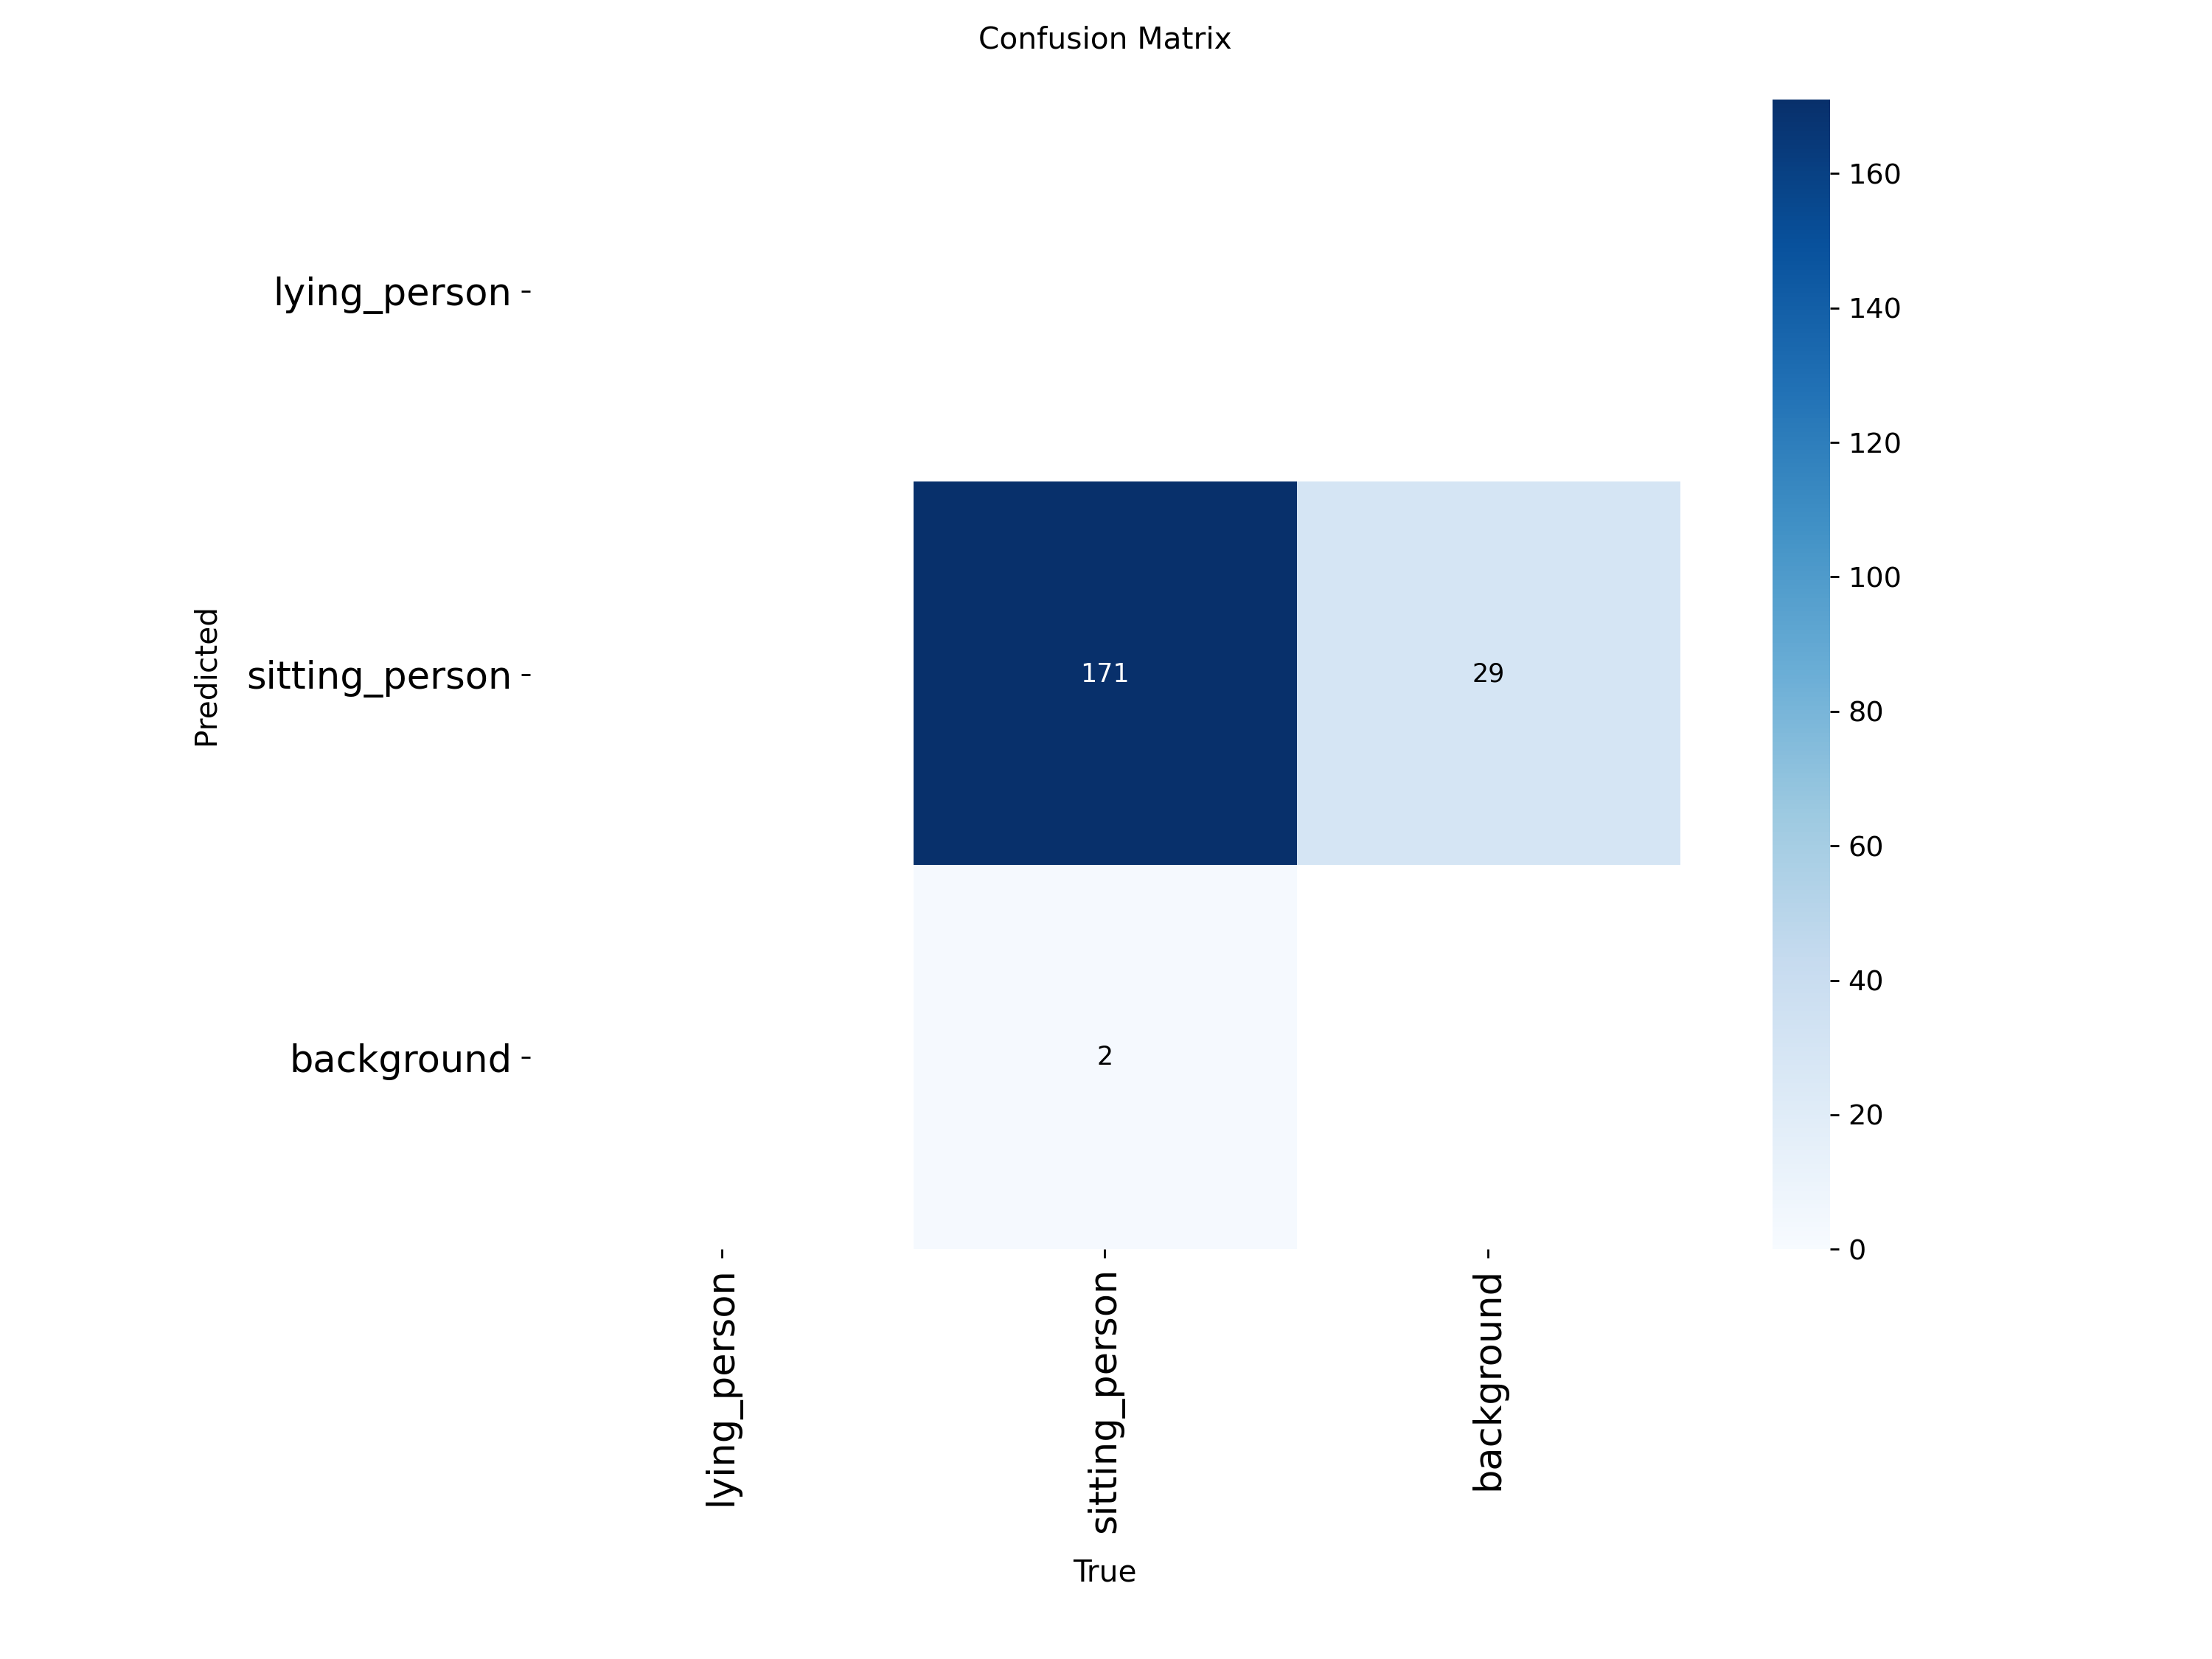

⚠️ val_batch0_pred.png not found
⚠️ F1_curve.png not found


In [8]:
# ============================================================
# CELL 8: DISPLAY TRAINING VISUALIZATIONS
# ============================================================
# WHY: Visual plots help you understand if training went well.
#
# WHAT EACH PLOT SHOWS:
# - results.png: Loss curves over time (should go DOWN)
# - confusion_matrix.png: Shows what the model gets right/wrong
# - val_batch0_pred.png: Actual predictions on validation images
# - F1_curve.png: F1 score at different confidence thresholds
#
# NOTE: With YOLO26, you'll see box_loss and cls_loss curves
# but NOT dfl_loss (it was removed in YOLO26's architecture).
# ============================================================

from IPython.display import Image, display
import os

results_dir = "/kaggle/working/yolo26_results/lying_sitting_v1"

# List of plots to display
plots = [
    ("results.png", "📈 Training & Validation Loss Curves",
     "All lines should trend DOWNWARD. If validation loss goes UP while "
     "training loss goes DOWN → overfitting (model is memorizing, not learning)."),

    ("confusion_matrix.png", "🔀 Confusion Matrix",
     "Diagonal = correct predictions. Off-diagonal = mistakes. "
     "High numbers on the diagonal = good!"),

    ("val_batch0_pred.png", "🖼️ Sample Predictions on Validation Images",
     "See how YOLO26n draws bounding boxes on images it has never seen."),

    ("F1_curve.png", "📊 F1-Score Curve",
     "F1 combines precision and recall. The peak shows the best "
     "confidence threshold to use for deployment."),
]

for filename, title, explanation in plots:
    filepath = os.path.join(results_dir, filename)
    if os.path.exists(filepath):
        print(f"\n{title}")
        print(f"💡 {explanation}")
        display(Image(filename=filepath, width=800))
    else:
        print(f"⚠️ {filename} not found")


🖼️ Test 1: ds1_img138_jpg.rf.10266f67c397becae343a9870ff54b4e.jpg

image 1/1 /kaggle/working/merged_dataset/valid/images/ds1_img138_jpg.rf.10266f67c397becae343a9870ff54b4e.jpg: 640x640 1 sitting_person, 8.7ms
Speed: 2.5ms preprocess, 8.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/yolo26_results/test_predictions_0


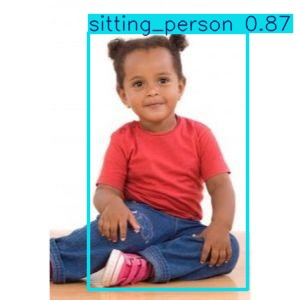

  🎯 Detected: sitting_person (confidence: 86.9%)

🖼️ Test 2: ds1_christina-wocintechchat-com-HocFQHhGjDE-unsplash_jpg.rf.34e324a8ad5a8809335e4b7dd1466037.jpg

image 1/1 /kaggle/working/merged_dataset/valid/images/ds1_christina-wocintechchat-com-HocFQHhGjDE-unsplash_jpg.rf.34e324a8ad5a8809335e4b7dd1466037.jpg: 640x480 2 sitting_persons, 55.1ms
Speed: 3.3ms preprocess, 55.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /kaggle/working/yolo26_results/test_predictions_1


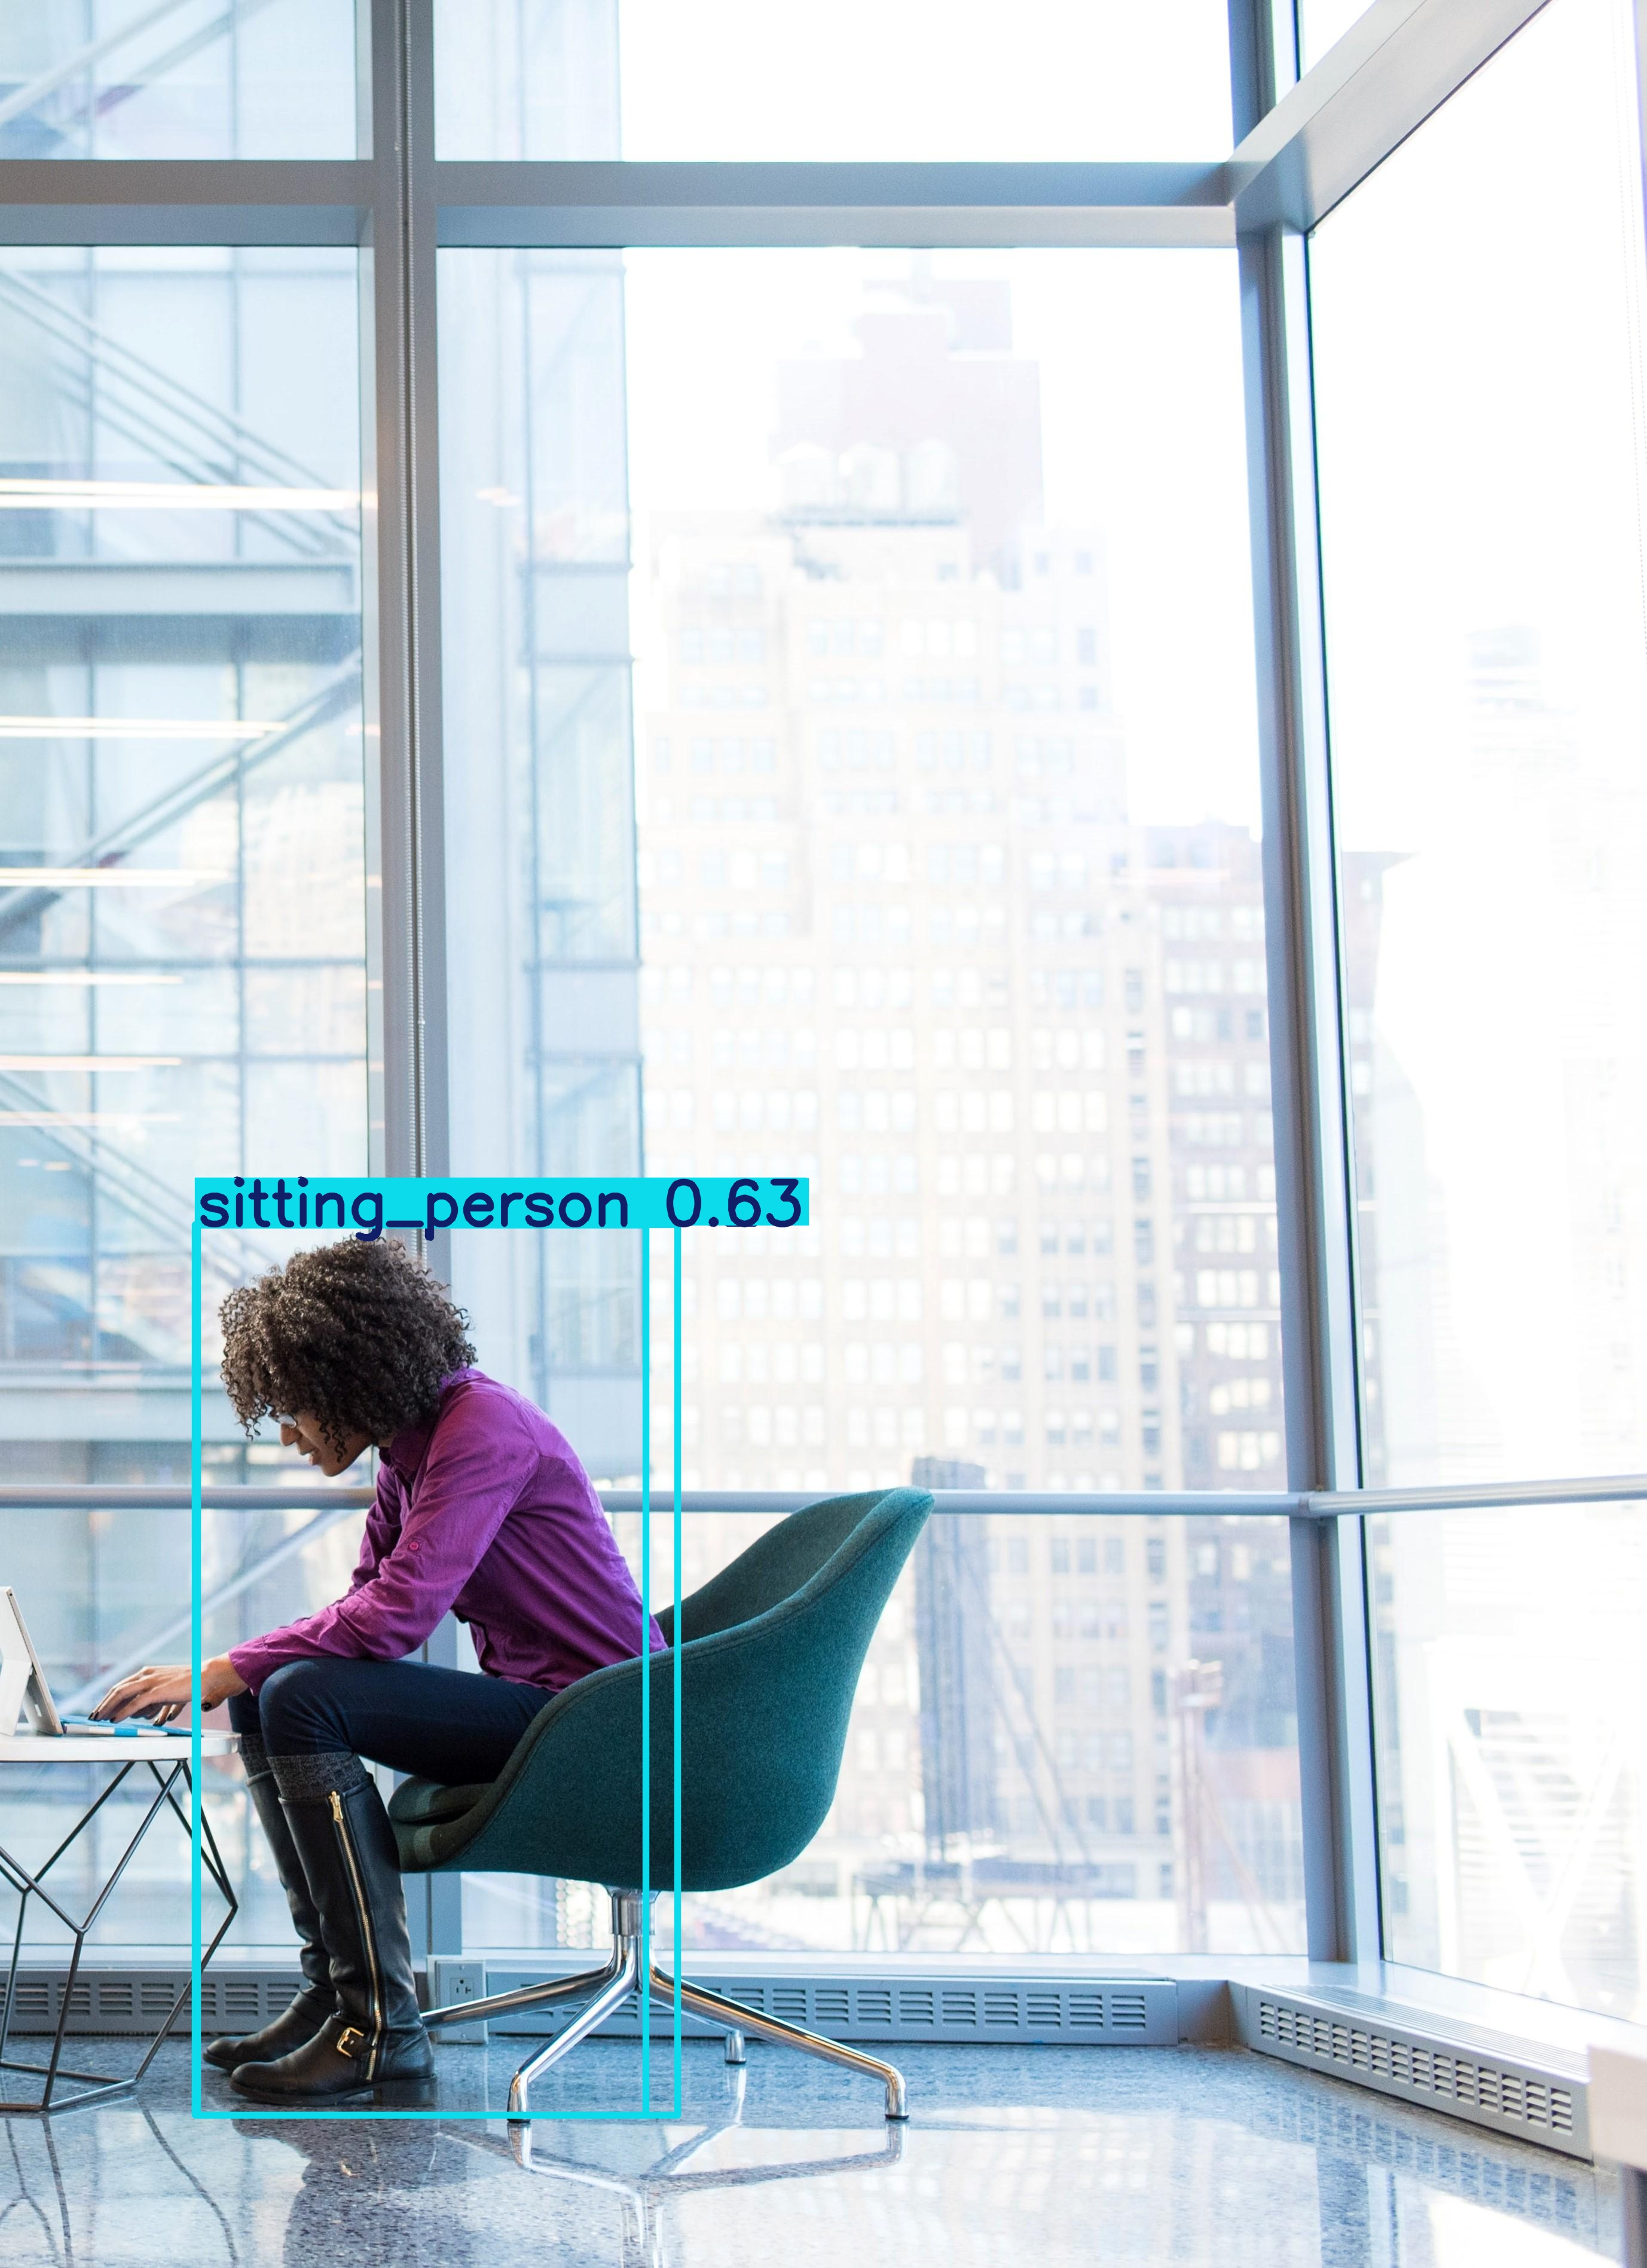

  🎯 Detected: sitting_person (confidence: 62.9%)
  🎯 Detected: sitting_person (confidence: 26.2%)

🖼️ Test 3: ds2_img128_jpg.rf.ab57c19aa535939f12528323f95b7162.jpg

image 1/1 /kaggle/working/merged_dataset/valid/images/ds2_img128_jpg.rf.ab57c19aa535939f12528323f95b7162.jpg: 640x640 1 sitting_person, 10.1ms
Speed: 2.1ms preprocess, 10.1ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/yolo26_results/test_predictions_2


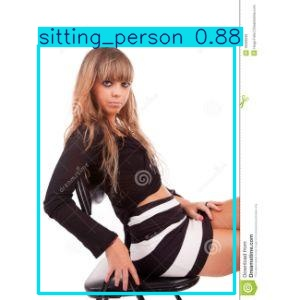

  🎯 Detected: sitting_person (confidence: 88.0%)


In [9]:
# ============================================================
# CELL 9: TEST THE MODEL ON A SAMPLE IMAGE
# ============================================================
# WHY: The best way to see if your model works is to try it!
# This picks a random image from the validation set and runs
# the model on it, then displays the result with bounding boxes.
#
# YOLO26 ADVANTAGE: Because YOLO26 is NMS-free, prediction is
# simpler — no post-processing needed. The model directly
# outputs clean, deduplicated detections.
# ============================================================

from ultralytics import YOLO
from IPython.display import Image, display
import random
import glob

# Load the best model
model = YOLO("/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.pt")

# Pick a random validation image
val_images = glob.glob(f"{MERGED_DIR}/valid/images/*")
if val_images:
    # Test on 3 random images to see variety
    sample_images = random.sample(val_images, min(3, len(val_images)))

    for i, test_img in enumerate(sample_images):
        print(f"\n🖼️ Test {i+1}: {os.path.basename(test_img)}")

        # Run prediction
        # conf=0.25 means "only show detections the model is ≥25% sure about"
        results = model.predict(
            source=test_img,
            conf=0.25,
            save=True,
            project="/kaggle/working/yolo26_results",
            name=f"test_predictions_{i}",
        )

        # Display the result
        pred_dir = f"/kaggle/working/yolo26_results/test_predictions_{i}"
        pred_images = glob.glob(f"{pred_dir}/*")
        if pred_images:
            display(Image(filename=pred_images[-1], width=600))

        # Print detection details
        for result in results:
            if len(result.boxes) == 0:
                print("  ⚠️ No detections in this image")
            for box in result.boxes:
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                class_name = model.names[class_id]
                print(f"  🎯 Detected: {class_name} (confidence: {confidence:.1%})")
else:
    print("❌ No validation images found")

In [10]:
# ============================================================
# CELL 10: EXPORT & SAVE THE TRAINED MODEL
# ============================================================
# WHY: You need to DOWNLOAD the trained model before the Kaggle
# session expires (12 hours max). Otherwise, you lose everything!
#
# EXPORT FORMATS EXPLAINED:
# - .pt (PyTorch)     → Use with Python/Ultralytics (default)
# - ONNX (.onnx)      → Universal format, works everywhere
# - TensorRT          → Optimized for NVIDIA GPUs (fastest)
# - TFLite            → For mobile phones (Android/iOS)
# - CoreML            → For Apple devices
#
# YOLO26 EXPORT ADVANTAGE:
#   Because YOLO26 is end-to-end (NMS-free), the exported model
#   is SELF-CONTAINED. You don't need to add NMS post-processing
#   code when deploying. The model handles everything internally!
# ============================================================

from ultralytics import YOLO
import shutil

model = YOLO("/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.pt")

# Export to ONNX format (works almost everywhere)
print("📦 Exporting to ONNX format...")
model.export(format="onnx", imgsz=640)
print("✅ ONNX export complete!")

# ---- Create a ZIP of everything important ----
print("\n📦 Creating downloadable ZIP file...")

export_dir = "/kaggle/working/model_export"
os.makedirs(export_dir, exist_ok=True)

# Copy the important files
files_to_save = [
    ("/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.pt", "best.pt"),
    ("/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.onnx", "best.onnx"),
    ("/kaggle/working/yolo26_results/lying_sitting_v1/weights/last.pt", "last.pt"),
    ("/kaggle/working/yolo26_results/lying_sitting_v1/results.png", "results.png"),
    ("/kaggle/working/yolo26_results/lying_sitting_v1/confusion_matrix.png", "confusion_matrix.png"),
    (f"{MERGED_DIR}/data.yaml", "data.yaml"),
]

for src, dst in files_to_save:
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(export_dir, dst))
        print(f"  ✅ Copied: {dst}")

# Create ZIP
shutil.make_archive("/kaggle/working/trained_yolo26n_model", 'zip', export_dir)
print(f"\n🎁 ZIP file created: /kaggle/working/trained_yolo26n_model.zip")
print(f"   📥 Click the file in the right sidebar → Output tab to download!")

# ---- Print final summary ----
print(f"\n{'='*60}")
print("🎉 ALL DONE! YOUR YOLO26n MODEL IS READY!")
print(f"{'='*60}")
print(f"""
📁 Key files:
   • best.pt   → The trained YOLO26n model (use this for predictions)
   • best.onnx → Portable version (for deployment anywhere)
   • last.pt   → The model from the very last epoch

🚀 To use your model later (on any computer with Python):

   pip install ultralytics
   
   from ultralytics import YOLO
   model = YOLO("best.pt")
   results = model.predict("photo.jpg", conf=0.25)
   results[0].show()  # Display with bounding boxes

🔑 YOLO26 Deployment Bonus:
   Your exported model is NMS-free (end-to-end), so you
   DON'T need any post-processing code when deploying!
   Just load → predict → done. It's that simple.

📥 DOWNLOAD NOW before your Kaggle session expires!
   Look for 'trained_yolo26n_model.zip' in:
   Right sidebar → Output tab → click to download
""")

📦 Exporting to ONNX format...
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 429ms
 Downloaded onnxruntime
Prepared 2 packages in 335ms
Installed 2 packages in 27ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.3s, saved as '/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.onnx' (9.4 MB)

Export complete (3.7s)
Results saved to /kaggle/working/yolo26_results/lying_sitting_v1/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/yolo26_results/lying_sitting_v1/weights/best.onnx imgsz=640 data=/kaggle/working/merged_dataset/data.yaml  
Visualize:       https://netron.app
✅ ONNX export complete!

📦 Creating downloadable ZIP file...
  ✅ Copied: best.pt
  ✅ Copied: best.onnx
  ✅ Copied: last.pt
  ✅ Copied: results.png
  ✅ Copied: confusion_matrix.png
  ✅ Copied: data.yaml

🎁 ZIP file created: /kaggle/working/trained_yolo26n_model.zip
   📥 Click the file in the right sidebar → Output tab to download!

🎉 ALL DONE! YOUR YOLO26n MODEL IS READY!

📁 Key files:
   • best.pt   → The t